In [55]:
import pandas as pd
import numpy as np
df = pd.read_csv('../data/test_volume_run.csv')
df.head()


,timestamp,open,high,low,close,volume
0,2026-03-01 00:00:00.005,0.09399,0.09420,0.09399,0.09414,2526210
1,2026-03-01 00:00:18.822,0.09414,0.09422,0.09409,0.09411,3966625
2,2026-03-01 00:00:44.346,0.09411,0.09414,0.09407,0.09413,897781
3,2026-03-01 00:01:13.858,0.09413,0.09414,0.09409,0.09412,3503489
4,2026-03-01 00:01:39.509,0.09411,0.09415,0.09404,0.09409,927781


In [56]:
df.describe() 

,open,high,low,close,volume
count,68789.000000,68789.000000,68789.000000,68789.000000,6.878900e+04
mean,0.094145,0.094197,0.094093,0.094145,2.868492e+06
std,0.003464,0.003468,0.003458,0.003464,2.754645e+06
min,0.086650,0.086700,0.086530,0.086670,3.490700e+04
25%,0.091420,0.091470,0.091380,0.091420,1.414108e+06
50%,0.093680,0.093740,0.093640,0.093690,2.202839e+06
75%,0.095970,0.096020,0.095910,0.095960,3.411010e+06
max,0.104410,0.104450,0.104300,0.104400,6.660680e+07


In [57]:
#求log_return
df['log_return']=np.log(df['close']/df['close'].shift(1))
df.dropna(inplace=True)
df.head()

,timestamp,open,high,low,close,volume,log_return
1,2026-03-01 00:00:18.822,0.09414,0.09422,0.09409,0.09411,3966625,-0.000319
2,2026-03-01 00:00:44.346,0.09411,0.09414,0.09407,0.09413,897781,0.000212
3,2026-03-01 00:01:13.858,0.09413,0.09414,0.09409,0.09412,3503489,-0.000106
4,2026-03-01 00:01:39.509,0.09411,0.09415,0.09404,0.09409,927781,-0.000319
5,2026-03-01 00:02:06.261,0.09410,0.09414,0.09408,0.09414,1257615,0.000531


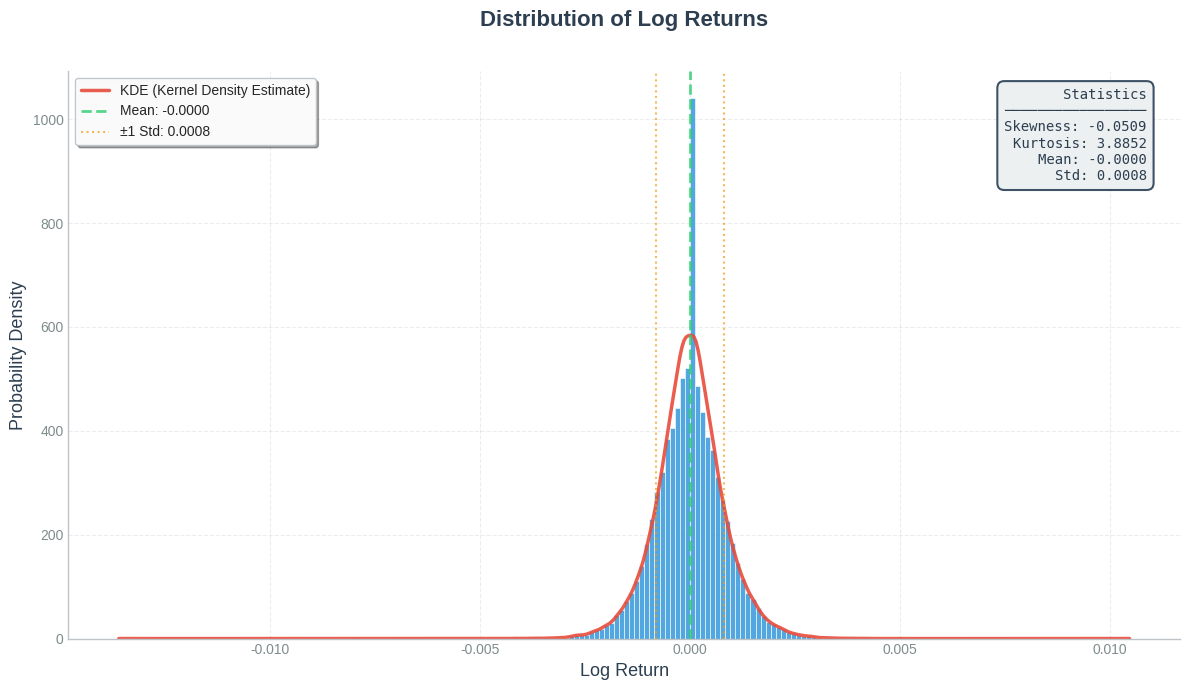

In [58]:
from scipy import stats
import seaborn as sns
import numpy as np
#绘制log_return的直方图观察分布
import matplotlib.pyplot as plt

# 设置中文字体和样式
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')

# 计算统计量
skewness = df['log_return'].skew()
kurtosis = df['log_return'].kurt()
mean_val = df['log_return'].mean()
std_val = df['log_return'].std()

# 创建图形，使用更优雅的配色
fig, ax = plt.subplots(figsize=(12, 7))

# 定义渐变色
colors = plt.cm.Blues(np.linspace(0.4, 0.9, 50))

# 绘制直方图（归一化处理），使用渐变色彩
n, bins, patches = ax.hist(df['log_return'], bins=200, density=True, 
                            alpha=0.85, color='#3498db', edgecolor='white', linewidth=0.5)

# 为每个柱子设置渐变颜色
for patch, color in zip(patches, colors):
    patch.set_facecolor(color)

# 添加KDE曲线，使用更优雅的样式
kde_x = np.linspace(df['log_return'].min(), df['log_return'].max(), 500)
kde = stats.gaussian_kde(df['log_return'].dropna())
ax.plot(kde_x, kde(kde_x), color='#e74c3c', linewidth=2.5, linestyle='-', 
        label='KDE (Kernel Density Estimate)', alpha=0.9)

# 添加均值和标准差参考线
ax.axvline(mean_val, color='#2ecc71', linestyle='--', linewidth=2, 
           label=f'Mean: {mean_val:.4f}', alpha=0.8)
ax.axvline(mean_val + std_val, color='#f39c12', linestyle=':', linewidth=1.5, 
           alpha=0.7, label=f'±1 Std: {std_val:.4f}')
ax.axvline(mean_val - std_val, color='#f39c12', linestyle=':', linewidth=1.5, alpha=0.7)

# 添加统计信息文本框，更美观的样式
textstr = (f'Statistics\n'
           f'─────────────────\n'
           f'Skewness: {skewness:.4f}\n'
           f'Kurtosis: {kurtosis:.4f}\n'
           f'Mean: {mean_val:.4f}\n'
           f'Std: {std_val:.4f}')
props = dict(boxstyle='round,pad=0.5', facecolor='#ecf0f1', 
             edgecolor='#34495e', alpha=0.95, linewidth=1.5)
ax.text(0.97, 0.97, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right', bbox=props,
        fontfamily='monospace', color='#2c3e50')

# 设置标签和标题，更精致的字体样式
ax.set_xlabel('Log Return', fontsize=13, fontweight='medium', color='#2c3e50')
ax.set_ylabel('Probability Density', fontsize=13, fontweight='medium', color='#2c3e50')
ax.set_title('Distribution of Log Returns\n', 
             fontsize=16, fontweight='bold', color='#2c3e50', pad=15)

# 优化图例样式
legend = ax.legend(loc='upper left', frameon=True, fancybox=True, 
                   shadow=True, fontsize=10, framealpha=0.95)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('#bdc3c7')

# 美化坐标轴
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#bdc3c7')
ax.spines['bottom'].set_color('#bdc3c7')
ax.tick_params(colors='#7f8c8d', labelsize=10)

# 添加网格线
ax.grid(True, alpha=0.3, linestyle='--', color='#bdc3c7')

plt.tight_layout()
plt.show()

In [59]:
#统计log_return大于0.01和小于-0.01的比例
positive_large = (df['log_return'] > 0.01).sum()
negative_large = (df['log_return'] < -0.01).sum()
print(f'Log Return > 0.01: {positive_large} ({positive_large/len(df)*100:.2f}%)')
print(f'Log Return < -0.01: {negative_large} ({negative_large/len(df)*100:.2f}%)')
#log_return大于0.01做空，小于-0.01做多这个策略不太行

Log Return > 0.01: 1 (0.00%)
Log Return < -0.01: 1 (0.00%)


In [60]:
import talib as ta
#计算布林带指标
df['upper_band'], df['middle_band'], df['lower_band'] = ta.BBANDS(df['close'], timeperiod=20)

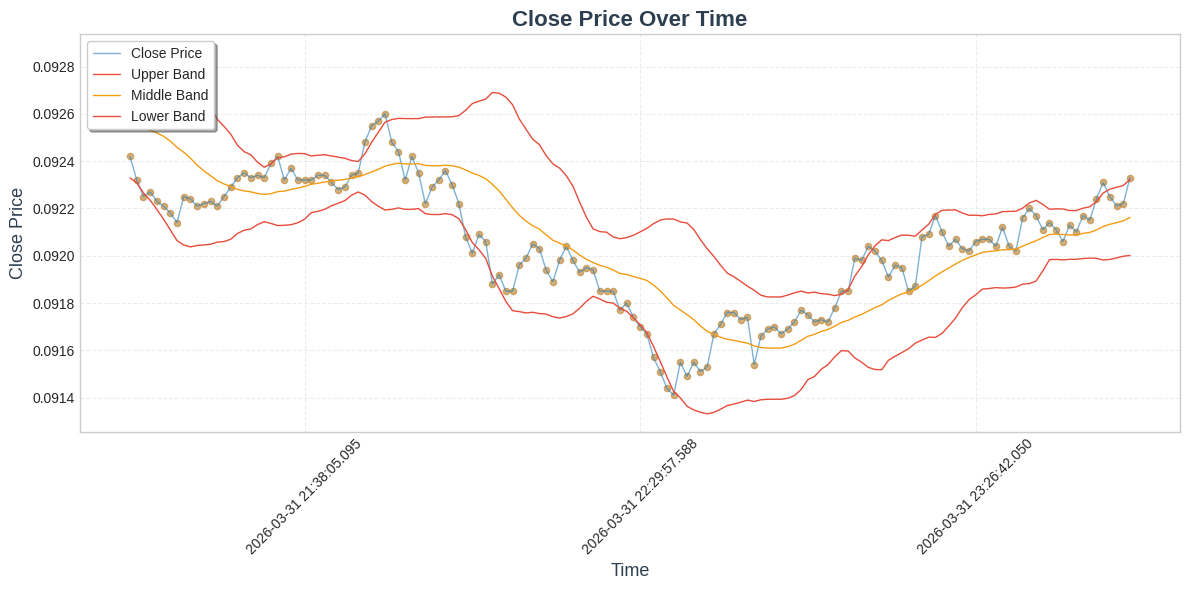

In [61]:
#绘制df['close']后500的散点图,df['upper_band'],df['middle_band'],df['lower_band'],观察趋势
count=150
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'][-count:], df['close'][-count:], color='#2980b9', linewidth=1, alpha=0.6, label='Close Price')
plt.scatter(df['timestamp'][-count:], df['close'][-count:], color="#b97d29", s=20, alpha=0.6)
plt.plot(df['timestamp'][-count:], df['upper_band'][-count:], color='#e74c3c', linewidth=1, label='Upper Band')
plt.plot(df['timestamp'][-count:], df['middle_band'][-count:], color='#f39c12', linewidth=1, label='Middle Band')
plt.plot(df['timestamp'][-count:], df['lower_band'][-count:], color='#e74c3c', linewidth=1, label='Lower Band')
plt.title('Close Price Over Time', fontsize=16, fontweight='bold', color='#2c3e50')
plt.xlabel('Time', fontsize=13, fontweight='medium', color='#2c3e50')
plt.ylabel('Close Price', fontsize=13, fontweight='medium', color='#2c3e50')
plt.legend(loc='upper left', frameon=True, fancybox=True, shadow=True, fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--', color='#bdc3c7')

# 减少x轴刻度数量，每隔一定天数显示一个标签
import matplotlib.dates as mdates
ax = plt.gca()
# 设置x轴日期格式和刻度间隔
ax.xaxis.set_major_locator(mdates.DayLocator(interval=50))  # 每50显示一个刻度

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()